In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [4]:
df=df.drop(columns=['id','Unnamed: 32'])

In [5]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
encoder=LabelEncoder()
y_train_scaled=encoder.fit_transform(y_train)
y_test_scaled=encoder.transform(y_test)

In [15]:
X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor  = torch.from_numpy(X_test_scaled).float()

y_train_tensor = torch.from_numpy(y_train_scaled).float().unsqueeze(1)
y_test_tensor  = torch.from_numpy(y_test_scaled).float().unsqueeze(1)


In [10]:
class NeuralNet:
    def __init__(self,X,y):
        self.w=torch.rand(X.shape[1],1,dtype=torch.float64,requires_grad=True)
        self.b=torch.zeros(1,dtype=torch.float64,requires_grad=True)

    def forward(self,X):
        z=torch.matmul(X,self.w)+self.b
        y_pred=torch.sigmoid(z)
        return y_pred

    def loss_fn(self, y, y_pred):
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

        loss = -(y * torch.log(y_pred) +
                (1 - y) * torch.log(1 - y_pred)).mean()
        return loss

        

In [20]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 3),
            nn.ReLU(),
            nn.Linear(3, 1) 
        )

    def forward(self, x):
        return self.network(x)

model = Model(X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [23]:
epochs = 1500
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")


Epoch 1: Loss = 0.4019
Epoch 2: Loss = 0.4008
Epoch 3: Loss = 0.3997
Epoch 4: Loss = 0.3986
Epoch 5: Loss = 0.3975
Epoch 6: Loss = 0.3964
Epoch 7: Loss = 0.3954
Epoch 8: Loss = 0.3943
Epoch 9: Loss = 0.3932
Epoch 10: Loss = 0.3921
Epoch 11: Loss = 0.3910
Epoch 12: Loss = 0.3900
Epoch 13: Loss = 0.3889
Epoch 14: Loss = 0.3878
Epoch 15: Loss = 0.3868
Epoch 16: Loss = 0.3857
Epoch 17: Loss = 0.3846
Epoch 18: Loss = 0.3836
Epoch 19: Loss = 0.3825
Epoch 20: Loss = 0.3814
Epoch 21: Loss = 0.3804
Epoch 22: Loss = 0.3793
Epoch 23: Loss = 0.3783
Epoch 24: Loss = 0.3772
Epoch 25: Loss = 0.3762
Epoch 26: Loss = 0.3751
Epoch 27: Loss = 0.3741
Epoch 28: Loss = 0.3730
Epoch 29: Loss = 0.3720
Epoch 30: Loss = 0.3709
Epoch 31: Loss = 0.3699
Epoch 32: Loss = 0.3689
Epoch 33: Loss = 0.3678
Epoch 34: Loss = 0.3668
Epoch 35: Loss = 0.3658
Epoch 36: Loss = 0.3648
Epoch 37: Loss = 0.3637
Epoch 38: Loss = 0.3627
Epoch 39: Loss = 0.3617
Epoch 40: Loss = 0.3607
Epoch 41: Loss = 0.3597
Epoch 42: Loss = 0.3587
E

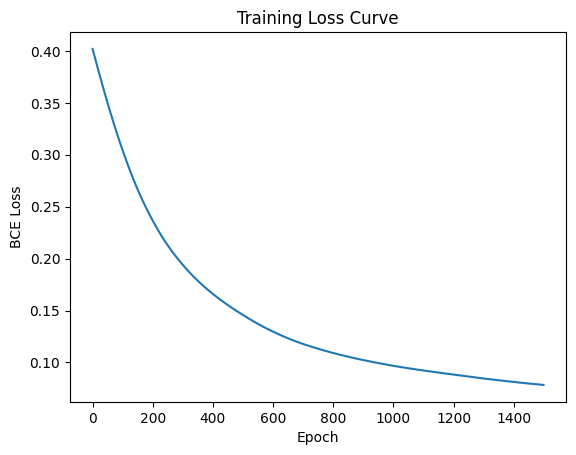

In [24]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss Curve")
plt.show()


In [25]:
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    acc = (preds == y_test_tensor).float().mean()
    print("Accuracy:", acc.item())


Accuracy: 0.9736841917037964


In [13]:
lr=0.01
epochs=250

In [18]:
model = NeuralNet(X_train_tensor, y_train_tensor)
losses=[]
for epoch in range(epochs):
    y_pred = model.forward(X_train_tensor)
    loss = model.loss_fn(y_train_tensor, y_pred)

    loss.backward()

    with torch.no_grad():
        model.w -= lr * model.w.grad
        model.b -= lr * model.b.grad

        model.w.grad.zero_()
        model.b.grad.zero_()
    losses.append(loss.item())
    print(f"Epoch:{epoch+1}: Loss:{loss.item():.4f}")


RuntimeError: expected m1 and m2 to have the same dtype, but got: float != double

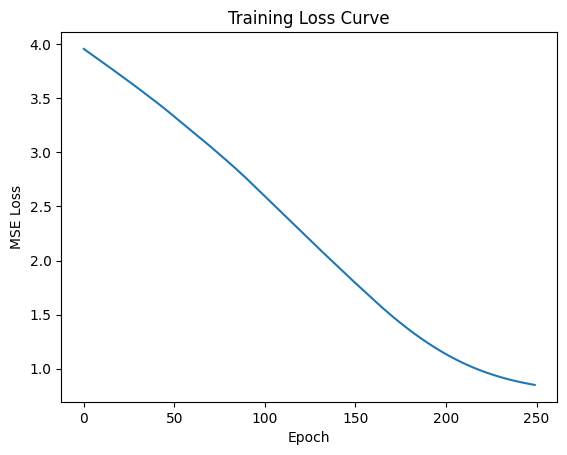

In [52]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()

In [56]:
with torch.no_grad():
    y_pred=model.forward(X_test_tensor)

    y_pred=(y_pred>0.9).float() 
    print((y_test_tensor==y_pred).float().mean())


tensor(0.6056)
